# Step-1 : Problem Definition

The Rain in Australia dataset contains about 10 years of daily weather observations from numerous Australian weather stations.

As a data scientist at the Bureau of Meteorology, you are tasked with creating a fully-automated system that can use
## ***Today's weather data for a given location to predict whether it will rain at the location tomorrow.***

We can use the features in the dataset given to create our model with adding a new Month feature because rain also effected by the month in simple words season.

**Note: We have to predict according to the Location.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Step-2 : Data Collection

In [ ]:
rawdf = pd.read_csv(r'weatherAUS.csv')

In [ ]:
rawdf

# Step-3 : Data Understanding, Exploratory Data Anylises, and Data Visualization

In [ ]:
rawdf.info()

While we should be able to fill in missing values for most columns, it might be a good idea to discard the rows where the value of **RainTomorrow** or **RainToday** is missing to make our analysis and modeling simpler (since one of them is the target variable, and the other is likely to be very closely related to the target variable).

In [ ]:
rawdf.dropna(subset=['RainToday', 'RainTomorrow'], inplace=True)

In [ ]:
rawdf.info()

# Visualizing data

MinTemp Vs RainTomorrow

In [ ]:
px.histogram(rawdf, x='MinTemp', color='RainTomorrow')

RainTomorrow Vs RainToday

In [ ]:
fig = px.scatter(rawdf, x='MinTemp', y='MaxTemp', hover_data='RainToday', opacity=0.5, color='RainTomorrow')
fig.show()

**Insights:**

1. From this plot we can see if the MinTemp and MaxTemp is as specific range then the probability of rain is very high.
2. If today rained that mean tomorrow there will a high chance of rain.

In [ ]:
px.histogram(rawdf,
             x='RainTomorrow',
             color='RainToday',
             title='RainTomorrow Vs RainToday')

In [ ]:
fig = px.scatter(rawdf, x='Humidity9am', hover_data='RainToday', opacity=0.5, color='RainTomorrow')
fig.show()

Month also affect the probability of rain.

In [ ]:
# Convert Date to datetime
rawdf['Date'] = pd.to_datetime(rawdf['Date'])

# Extract month name
#rawdf['Month'] = rawdf['Date'].dt.month_name()
rawdf.insert(loc=1, column='Month', value = rawdf['Date'].dt.month)

In [ ]:
rawdf

In [ ]:
px.histogram(rawdf, x='Month', y = 'RainTomorrow', color='RainToday')

In [ ]:
rawdf[(rawdf['RainToday'] == 1) & (rawdf['RainTomorrow']==1) & (rawdf['Month'] == 6)]['RainTomorrow'].count()

We can see that the Month has a veryy little affect on `RainToday` and `RainTomorrow`

Checking the number of days it `RainToday` according to the `Location`.

In [ ]:
px.histogram(rawdf,
             x='Location',
             color='RainToday')

Checking the probability of `RainTomorrow` according to the `Location`

In [ ]:

# Use this one after the data cleaning and encoding
'''

px.histogram(
          rawdf,
          x='Location',
          color='RainToday',
          hist = 'avg',
          y='RainTomorrow',
          labels={'RainTomorrow': 'Probability of Rain Tomorrow'}
)
'''

At all Location the probability of `RainTomorrow` significantly increases as if it is `RainToday`

In [ ]:
rawdf.columns

Temp3pm Vs Humidity3pm

In [ ]:
px.scatter(rawdf.sample(10000),
           x='Temp3pm',
           y='Humidity3pm',
           opacity=0.6,
           hover_data='RainToday',
           color='RainTomorrow',
           title='Temp3pm Vs Humidity3pm')

Temp9am Vs Humidity9am

In [ ]:
px.scatter(rawdf.sample(10000),
           x='Temp9am',
           y='Humidity9am',
           opacity=0.6,
           hover_data='RainToday',
           color='RainTomorrow',
           title='Temp9am Vs Humidity9am')

MinTemp Vs MaxTemp

In [ ]:
px.scatter(rawdf.sample(10000),
           x='MinTemp',
           y='MaxTemp',
           color='RainTomorrow',
           hover_data='RainToday',
           title='MinTemp Vs MaxTemp',
           opacity=0.7)

Least the `MaxTemp` and `MinTemp` more the probability of `RainTomorrow`

As the `Humidity3pm` increases the Probability of `RainTomorrow` significantly increases also increase but with increase in temperature `Humidity3pm` decreases and Probability of `RainTomorrow` significantly decreases.

Droping the Month feature created because according to the problem we should not include it as it does not mention it.

In [ ]:
rawdf = rawdf.drop('Month', axis = 1)

# Step-4: Data Cleaning

Filling the null values with mean values according to their column values.

In [ ]:
rawdf.columns

In [ ]:
have_null_cols = ['MinTemp', 'MaxTemp', 'Rainfall',
                  'Evaporation', 'Sunshine', 'WindGustDir',
                  'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
                  'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
                  'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                  'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

In [ ]:
# for i in have_null_cols:
#   rawdf[i] = rawdf[i].interpolate(mehtod='linear', inplace=True)
'''
    the above code cannot be used because the have_null_cols also
    contains columns having non-numeric values.
'''

# numeric_null_cols = rawdf[have_null_cols].select_dtypes(include=number).columns
# for i in numeric_null_cols:
#   rawdf[i] = rawdf[i].interpolate(method='linear')
'''
    this one is not working properly
'''

#rawdf.select_dtypes(include='number').interpolate(method='linear', inplace=True)
'''
    Never use this unsafe due to temporary dataframe by
    select_dtype with shuffeled order of columns
'''

Selecting the features having numeric values only.

In [ ]:
numeric_cols = rawdf.select_dtypes(include='number').columns
numeric_cols

Filling the null values using intrpolation liner method wiht both direction parameters

In [ ]:
rawdf[numeric_cols] = rawdf[numeric_cols].interpolate(method='linear', limit_direction='both')

In [ ]:
## Another method using Sklearn for filling missing values ##

# imputer = SimpleImputer(strategy = 'mean')
# imputer.fit(raw_df[numeric_cols])
# list(imputer.statistics_)
# rawdf[numeric_cols] = imputer.transform(rawdf[numeric_cols])

In [ ]:
rawdf.info()

Successfully filled the numerical data.

Filling the catagorical data with most frequent data

In [ ]:
# cat_cols = rawdf.select_dtypes(include='object').columns
# rawdf[cat_cols] = rawdf[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

In [ ]:
rawdf.info()

In [ ]:
print(rawdf.Location.unique())
print(len(rawdf.Location.unique()))

print(rawdf.WindGustDir.unique())
print(len(rawdf.WindGustDir.unique()))

print(rawdf.WindDir9am.unique())
print(len(rawdf.WindDir9am.unique()))

print(rawdf.WindDir3pm.unique())
print(len(rawdf.WindDir3pm.unique()))

# Step-6 : One-Hot Encoding
We can perform one hot encoding using the OneHotEncoder class from sklearn.preprocessing.

Try to do the encoding of binary features manually. If 3-4 binary features only.

In [ ]:
rawdf['RainToday'] = (rawdf['RainToday']=='Yes').astype(int)
rawdf['RainTomorrow'] = (rawdf['RainTomorrow']=='Yes').astype(int)

In [ ]:
num_cols = rawdf.select_dtypes(include='number').columns
cat_cols = rawdf.select_dtypes(include='object').columns

In [ ]:
num_cols, cat_cols

In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [ ]:
encoder.fit(rawdf[cat_cols]) #excepts only two dimensional data

In [ ]:
#using catagories_ attribute we can check the what categories our Encoder
# separated out.
encoder.categories_

In [ ]:
encoded_cols = list(encoder.get_feature_names_out(cat_cols))
encoded_cols

In [ ]:
#rawdf[encoded_cols] = encoder.transform(rawdf['cat_cols'])
# the above is giving error because
'''
The output is a PerformanceWarning. This warning indicates
that repeatedly adding new columns to the rawdf DataFrame
is making it 'highly fragmented', which can lead to poor
performance. This typically happens when you add columns
one by one in a loop or by assigning multiple new columns
directly. The recommended way to fix this is to create all
new columns at once and then concatenate them with the
original DataFrame. I will modify the code to address this
warning.
'''

encoded_df = pd.DataFrame(encoder.transform(rawdf[cat_cols]), columns=encoded_cols, index=rawdf.index)
rawdf = pd.concat([rawdf, encoded_df], axis=1)

In [ ]:
print(rawdf.head())
print(rawdf.columns)

Now every Catagorical column has been converted into numreical column using binary conversion and One-Hot Encoding

# Step-7 : Feature Scaling

Using two copies of rawdf so that I can try prediction using two different scaling methods.


Another good practice is to scale numeric features to a small range of values e.g. (-1,1) or (0,1).

Scaling numeric features ensures that no particular feature has a **disproportionate impact on the model's loss**. *Optimization algorithms also work better in practice with smaller numbers.*

The numeric columns in our dataset have varying ranges.

In [ ]:
ssdf = rawdf.copy()
mmsdf = rawdf.copy()

# 1. Using MinMaxScaler

In [ ]:
mmscaler = MinMaxScaler()

First we fit our DataSet for the model to get Minimum, Maximum and other data about our dataset.

In [ ]:
mmscaler.fit(mmsdf[num_cols])

In [ ]:
print('Minimum:')
mmscaler.data_min_

In [ ]:
print('Maximim: ')
mmscaler.data_max_

Now we can scale our train, validation and test data using transform.

In [ ]:
mmsdf[num_cols] = mmscaler.transform(mmsdf[num_cols])

In [ ]:
type(mmsdf)

# 2. Using StandardScaler

In [ ]:
sscaler = StandardScaler()

Fitting our whole Dataset

In [ ]:
sscaler.fit(ssdf[num_cols])

In [ ]:
ssdf[num_cols] = sscaler.transform(ssdf[num_cols])

Training, Validation and Test Sets
While building real-world machine learning models, it is quite common to split the dataset into three parts:

1. Training set - used to train the model, i.e., compute the loss and adjust the model's weights using an optimization technique.

2. Validation set - used to evaluate the model during training, tune model hyperparameters (optimization technique, regularization etc.), and pick the best version of the model. Picking a good validation set is essential for training models that generalize well. Learn more here.

3. Test set - used to compare different models or approaches and report the model's final accuracy. For many datasets, test sets are provided separately. The test set should reflect the kind of data the model will encounter in the real-world, as closely as feasible.

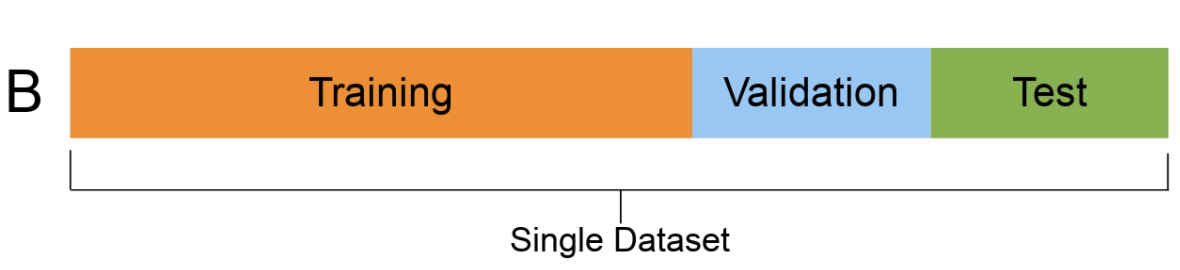https://i.imgur.com/j8eITrK.png

As a general rule of thumb you can use around 60% of the data for the training set, 20% for the validation set and 20% for the test set. If a separate test set is already provided, you can use a 75%-25% training-validation split.

When rows in the dataset have no inherent order, it's common practice to pick random subsets of rows for creating test and validation sets. This can be done using the train_test_split utility from scikit-learn. Learn more about it here: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [ ]:
mmstrain_val_df, mmstest_df = train_test_split(mmsdf, test_size=0.2, random_state=53)
mmstrain_df, mmsval_df = train_test_split(mmsdf, test_size=0.2, random_state=33)

sstrain_val_df, sstest_df = train_test_split(ssdf, test_size=0.2, random_state=53)
sstrain_df, ssval_df = train_test_split(ssdf, test_size=0.2, random_state=33)

In [ ]:
print('for min max scaler df:')
print('train_df.shape :', mmstrain_df.shape)
print('val_df.shape :', mmsval_df.shape)
print('test_df.shape :', mmstest_df.shape)

print('\nfor standard scaler df:')
print('train_df.shape :', sstrain_df.shape)
print('val_df.shape :', ssval_df.shape)
print('test_df.shape :', sstest_df.shape)

However, while working with dates, it's often a better idea to separate the training, validation and test sets with time, so that the model is trained on data from the past and evaluated on data from the future.

For the current dataset, we can use the Date column in the dataset to create another column for year. We'll pick the last two years for the test set, and one year before it for the validation set.

In [ ]:
year = pd.to_datetime(rawdf.Date).dt.year
year

In [ ]:
plt.hist(year, rwidth=0.7, align='right')
plt.xticks([2006] + [i for i in year.unique()])
plt.title('Number of samples per year')
plt.show()
#don't know why the matlplotlib histogram showing wrong details

#or

plt.title('No. of Rows per Year')
sns.countplot(x=year);

In [ ]:
train_df = rawdf[year < 2015]
val_df = rawdf[year == 2015]
test_df = rawdf[year > 2015]

train_df = rawdf[year < 2015]
val_df = rawdf[year == 2015]
test_df = rawdf[year > 2015]

In [ ]:
print('train_df shape: ', train_df.shape)
print('val_df shape: ', val_df.shape)
print('test_df shape: ', test_df.shape)